<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 8

  **(QN)** IMPLEMENT the standard LetNet-5 CNN arch model to classify multcategory image dataset (MNIST, Fashion MNIST) and check the accuracy.

# STEPS

1. Import python packages
2. Load the Mnist dataset
3. Data preprocessing
4. Define Model Architecture
5. Training
6. Model evaluation

In [ ]:
#Import packages
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [ ]:
#Load Dataset
(train_x,train_y), (test_x,test_y) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#Data Preprocessong
train_x = train_x / 255.0
test_x = test_x / 255.0
train_x = tf.expand_dims(train_x,3)
test_x = tf.expand_dims(test_x,3)

val_x = train_x[:5000]
val_y = train_y[:5000]



In [ ]:
#Model Architecture

lenet_5_model = keras.models.Sequential([
    keras.layers.Conv2D(6, kernel_size=5, strides=1, activation='tanh', input_shape=train_x[0].shape, padding='same'),
    keras.layers.AveragePooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(16, kernel_size=5, strides=1, activation='tanh', padding='valid'),
    keras.layers.AveragePooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(84, activation='tanh'),
    keras.layers.Dense(10, activation='tanh'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
lenet_5_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        33,684 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,106 (144.95 KB)

 Trainable params: 37,106 (144.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train the Model

lenet_5_model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
lenet_5_model.fit(train_x, train_y, epochs=10, validation_data=(val_x, val_y))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.9258 - loss: 0.9584 - val_accuracy: 0.9718 - val_loss: 0.8591
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9713 - loss: 0.8542 - val_accuracy: 0.9838 - val_loss: 0.8343
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9801 - loss: 0.8357 - val_accuracy: 0.9874 - val_loss: 0.8265
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9844 - loss: 0.8271 - val_accuracy: 0.9912 - val_loss: 0.8180
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9870 - loss: 0.8220 - val_accuracy: 0.9902 - val_loss: 0.8172
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9886 - loss: 0.8186 - val_accuracy: 0.9898 - val_loss: 0.8161
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9900 - loss: 0.8159 - val_accuracy: 0.9924 - val_loss: 0.8122
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9909 -

In [ ]:
#Model Evaluation

lenet_5_model.evaluate(test_x, test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9892 - loss: 0.8178


[0.81778883934021, 0.9891999959945679]

In [ ]:
#Predictions

predictions = lenet_5_model.predict(test_x)
print(np.argmax(np.round(predictions[0])))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
7


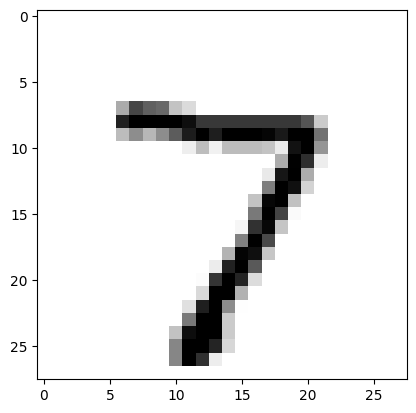

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(test_x[0], cmap = plt.cm.binary)
plt.show()